## Libraries and Data Loading

In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt

In [2]:
df = pl.read_csv("../data/collaborative_filtering/train.csv")
df.head(5)

user,item,rating
i64,i64,f64
1,25715,7.0
1,25716,10.0
5,25851,9.0
6,25923,5.0
7,25924,6.0


# Basic Info about the dataset

In [3]:
duckdb.sql("""
    SELECT AVG(rating) AS avg_rating, COUNT(*) AS num_ratings, max(rating) AS max_rating, min(rating) AS min_rating
    FROM df
           """)

┌───────────────────┬─────────────┬────────────┬────────────┐
│    avg_rating     │ num_ratings │ max_rating │ min_rating │
│      double       │    int64    │   double   │   double   │
├───────────────────┼─────────────┼────────────┼────────────┤
│ 7.604666056958993 │      390351 │       10.0 │        1.0 │
└───────────────────┴─────────────┴────────────┴────────────┘

In [4]:
duckdb.sql("""    
    SELECT COUNT(DISTINCT user) AS num_users
    FROM df
           """)

┌───────────┐
│ num_users │
│   int64   │
├───────────┤
│     73456 │
└───────────┘

In [5]:
duckdb.sql("""    
    SELECT COUNT(DISTINCT item) AS num_items
    FROM df
           """)

┌───────────┐
│ num_items │
│   int64   │
├───────────┤
│    171171 │
└───────────┘

# How many votes has a rating

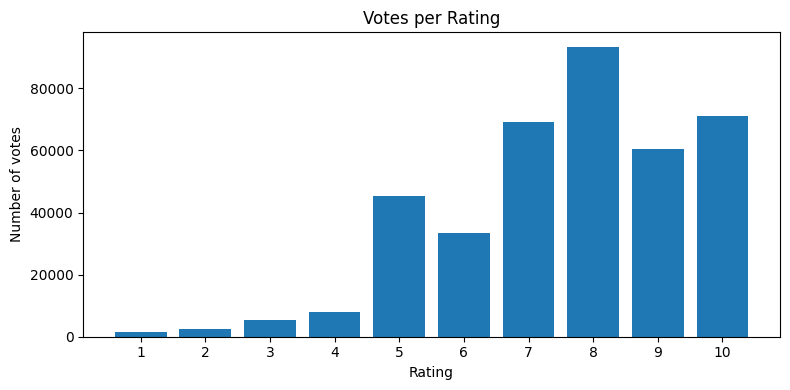

In [6]:
rating_votes = duckdb.sql("""
    SELECT rating, COUNT(*) AS num_votes
    FROM df
    GROUP BY rating
    ORDER BY rating
""").pl()

plt.figure(figsize=(8, 4))
plt.bar(rating_votes["rating"].to_list(), rating_votes["num_votes"].to_list())
plt.xlabel("Rating")
plt.ylabel("Number of votes")
plt.title("Votes per Rating")
plt.xticks(rating_votes["rating"].to_list())
plt.tight_layout()
plt.show()

# Metrics by user

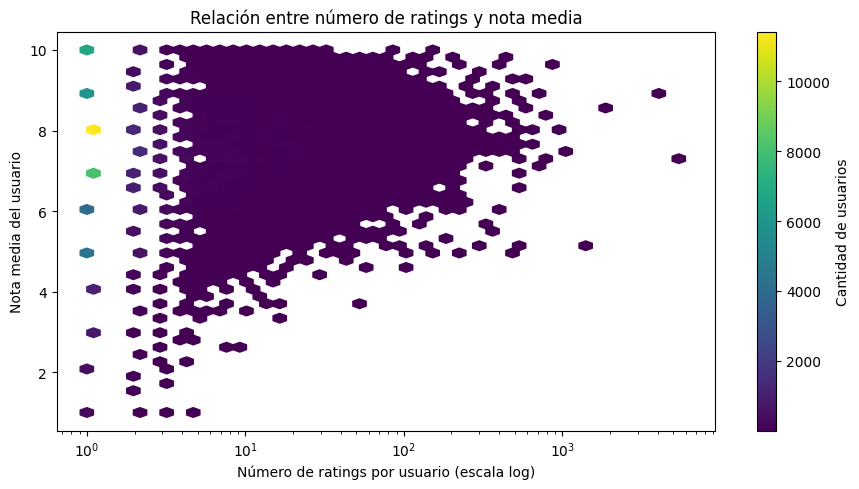

In [7]:
user_metrics = duckdb.sql("""
    SELECT
        user,
        COUNT(*) AS num_ratings,
        AVG(rating) AS avg_rating
    FROM df
    GROUP BY user
""").pl()

plt.figure(figsize=(9, 5))
hb = plt.hexbin(
    user_metrics["num_ratings"].to_numpy(),
    user_metrics["avg_rating"].to_numpy(),
    gridsize=45,
    cmap="viridis",
    mincnt=1,
    xscale="log"
)
plt.colorbar(hb, label="Cantidad de usuarios")
plt.xlabel("Número de ratings por usuario (escala log)")
plt.ylabel("Nota media del usuario")
plt.title("Relación entre número de ratings y nota media")
plt.tight_layout()
plt.show()

# duckdb.sql("""
#            SELECT user, COUNT(*) AS num_ratings, AVG(rating) AS avg_rating
#               FROM df   

#                 GROUP BY user
#                 ORDER BY num_ratings DESC
#             """       
           
#            ).pl()

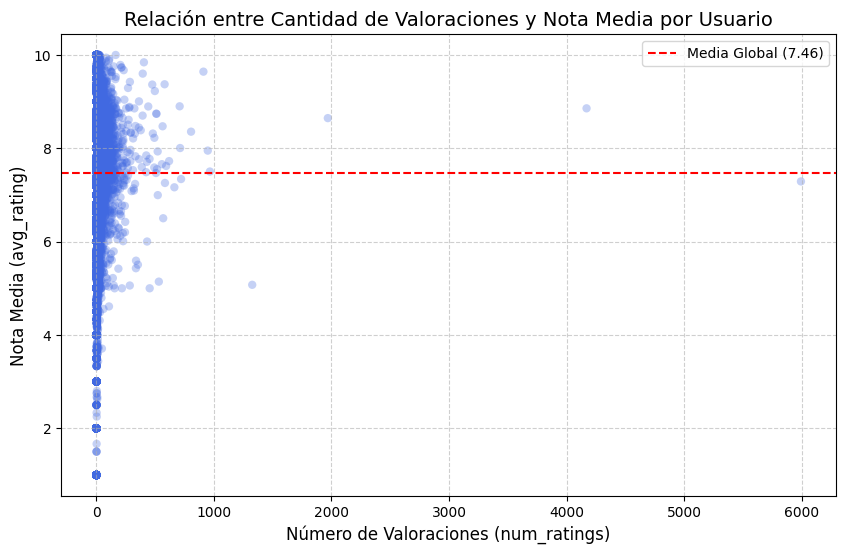

In [8]:
# Extraemos las columnas del DataFrame de Polars
x = user_metrics['num_ratings']
y = user_metrics['avg_rating']

plt.figure(figsize=(10, 6))
# alpha=0.3 hace que los puntos sean semitransparentes
plt.scatter(x, y, alpha=0.3, color='royalblue', edgecolor='none')

plt.title('Relación entre Cantidad de Valoraciones y Nota Media por Usuario', fontsize=14)
plt.xlabel('Número de Valoraciones (num_ratings)', fontsize=12)
plt.ylabel('Nota Media (avg_rating)', fontsize=12)

# Añadimos una línea horizontal con la media global de todas las notas para tener referencia
plt.axhline(y.mean(), color='red', linestyle='--', label=f'Media Global ({y.mean():.2f})')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

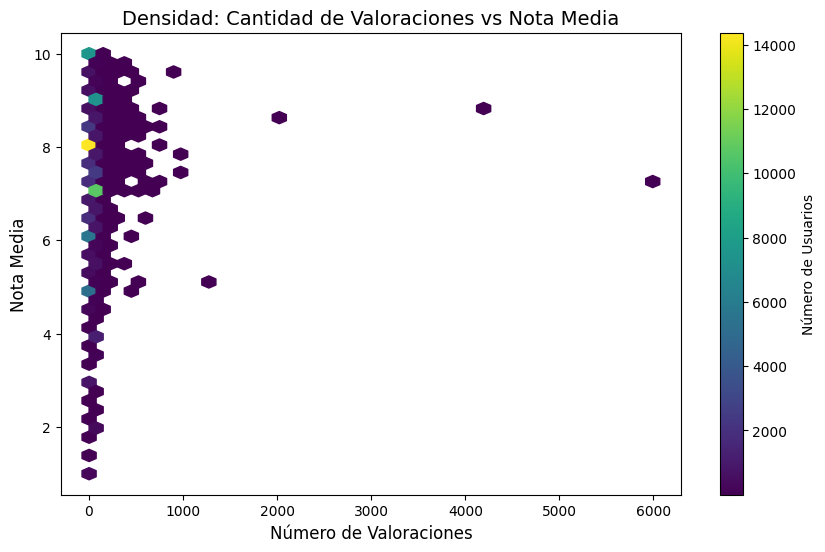

In [9]:
x = user_metrics['num_ratings']
y = user_metrics['avg_rating']

plt.figure(figsize=(10, 6))
# gridsize define el tamaño de los hexágonos (mayor número = hexágonos más pequeños)
# mincnt=1 evita dibujar hexágonos vacíos
hb = plt.hexbin(x, y, gridsize=40, cmap='viridis', mincnt=1)

plt.title('Densidad: Cantidad de Valoraciones vs Nota Media', fontsize=14)
plt.xlabel('Número de Valoraciones', fontsize=12)
plt.ylabel('Nota Media', fontsize=12)

# Añadimos la barra de color lateral para entender la escala de densidad
cb = plt.colorbar(hb)
cb.set_label('Número de Usuarios')

plt.show()

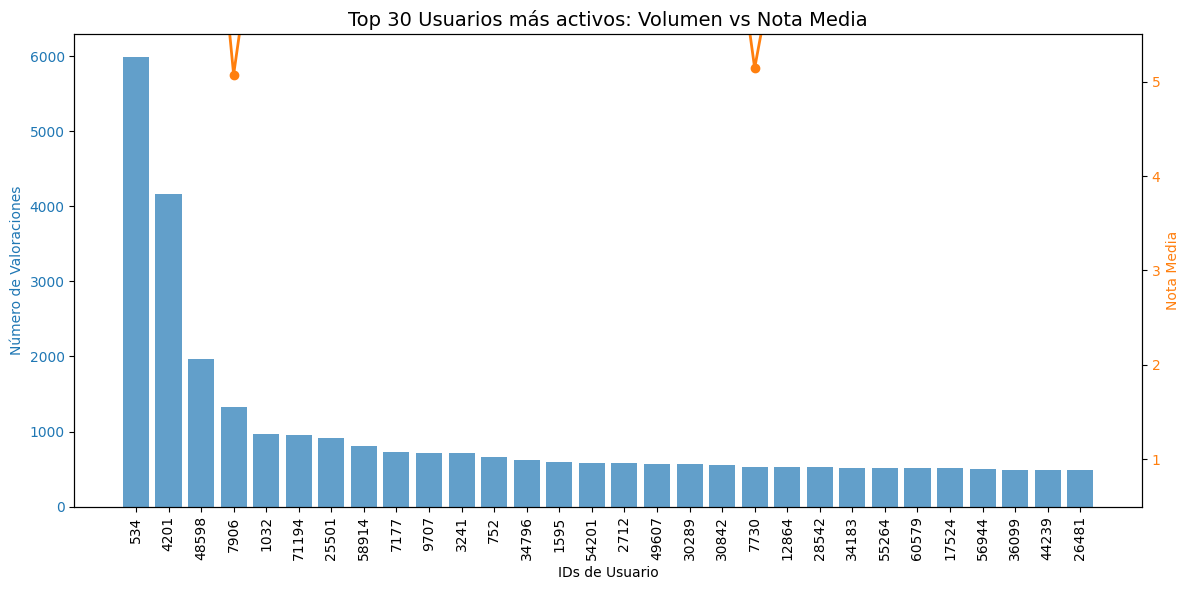

In [10]:
top_users = user_metrics.sort('num_ratings', descending=True).head(30)

users = top_users['user'].to_list() # Convertir a lista para los labels si es necesario
counts = top_users['num_ratings']
avgs = top_users['avg_rating']

# Crear figura y el primer eje (para las barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('IDs de Usuario')
ax1.set_ylabel('Número de Valoraciones', color=color)
ax1.bar(range(len(users)), counts, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(users)))
ax1.set_xticklabels(users, rotation=90) # Rotar IDs para que se lean

# Crear el segundo eje que comparte el mismo eje X
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Nota Media', color=color)  
# Dibujamos la nota media con puntos y líneas
ax2.plot(range(len(users)), avgs, color=color, marker='o', linestyle='-', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Limitar el eje Y de la nota para que la perspectiva sea clara (ej. notas de 1 a 5)
ax2.set_ylim(0.5, 5.5) 

plt.title('Top 30 Usuarios más activos: Volumen vs Nota Media', fontsize=14)
fig.tight_layout()  # Ajusta el layout para que no se corten las etiquetas
plt.show()

# Positive VS Negative Ratings

In [11]:
df_positiveness = duckdb.sql("""
    SELECT user, item, rating, IF(rating >= 4, 'Positive', 'Negative') AS rating_type
    FROM df
    """).pl()
df_positiveness.head(5)

user,item,rating,rating_type
i64,i64,f64,str
1,25715,7.0,"""Positive"""
1,25716,10.0,"""Positive"""
5,25851,9.0,"""Positive"""
6,25923,5.0,"""Positive"""
7,25924,6.0,"""Positive"""


In [12]:
duckdb.sql("""
            SELECT rating_type, COUNT(*) AS num_ratings
            FROM df_positiveness
            GROUP BY rating_type
           """)

┌─────────────┬─────────────┐
│ rating_type │ num_ratings │
│   varchar   │    int64    │
├─────────────┼─────────────┤
│ Positive    │      380858 │
│ Negative    │        9493 │
└─────────────┴─────────────┘

In [13]:
df_posi = duckdb.sql("""
        SELECT
            user,
            SUM(CASE WHEN rating_type = 'Positive' THEN 1 ELSE 0 END) AS num_positive_ratings,
            SUM(CASE WHEN rating_type = 'Negative' THEN 1 ELSE 0 END) AS num_negative_ratings,
            (num_positive_ratings * 100.0 / NULLIF(num_positive_ratings + num_negative_ratings, 0)) AS positive_percentage,
            num_positive_ratings + num_negative_ratings AS total_ratings
        FROM df_positiveness
        GROUP BY user
        ORDER BY user
           """).pl()
df_posi.head(5)

user,num_positive_ratings,num_negative_ratings,positive_percentage,total_ratings
i64,"decimal[38,0]","decimal[38,0]",f64,"decimal[38,0]"
1,2,0,100.0,2
5,1,0,100.0,1
6,1,0,100.0,1
7,6,0,100.0,6
9,4,0,100.0,4


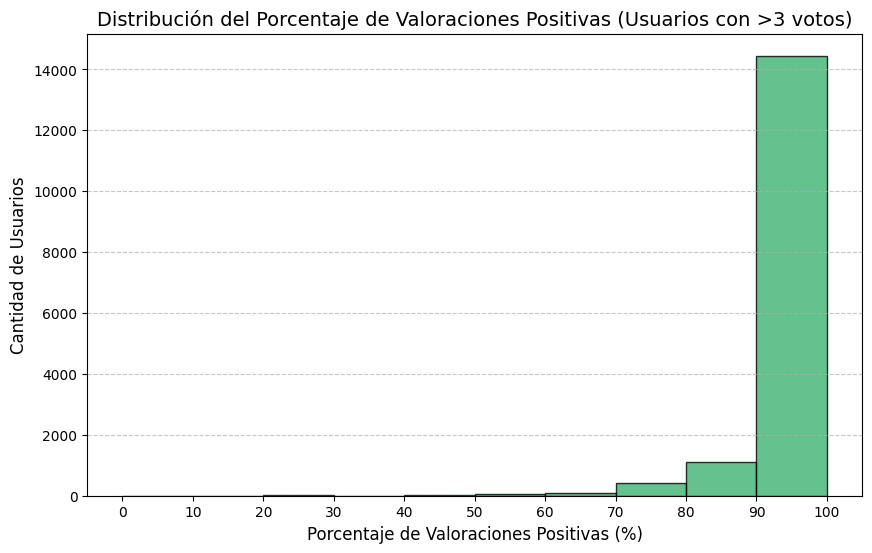

In [15]:
# Filtramos (opcionalmente) usuarios con más de 3 votos para evitar el sesgo de la primera valoración
df_filtered = df_posi.filter(df_posi['total_ratings'] > 3)
porcentajes = df_filtered['positive_percentage'].to_list()

plt.figure(figsize=(10, 6))
# Creamos el histograma con bins de 10 en 10
plt.hist(porcentajes, bins=10, range=(0, 100), color='mediumseagreen', edgecolor='black', alpha=0.8)

plt.title('Distribución del Porcentaje de Valoraciones Positivas (Usuarios con >3 votos)', fontsize=14)
plt.xlabel('Porcentaje de Valoraciones Positivas (%)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.xticks(range(0, 101, 10)) # Marcas en el eje X de 10 en 10
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

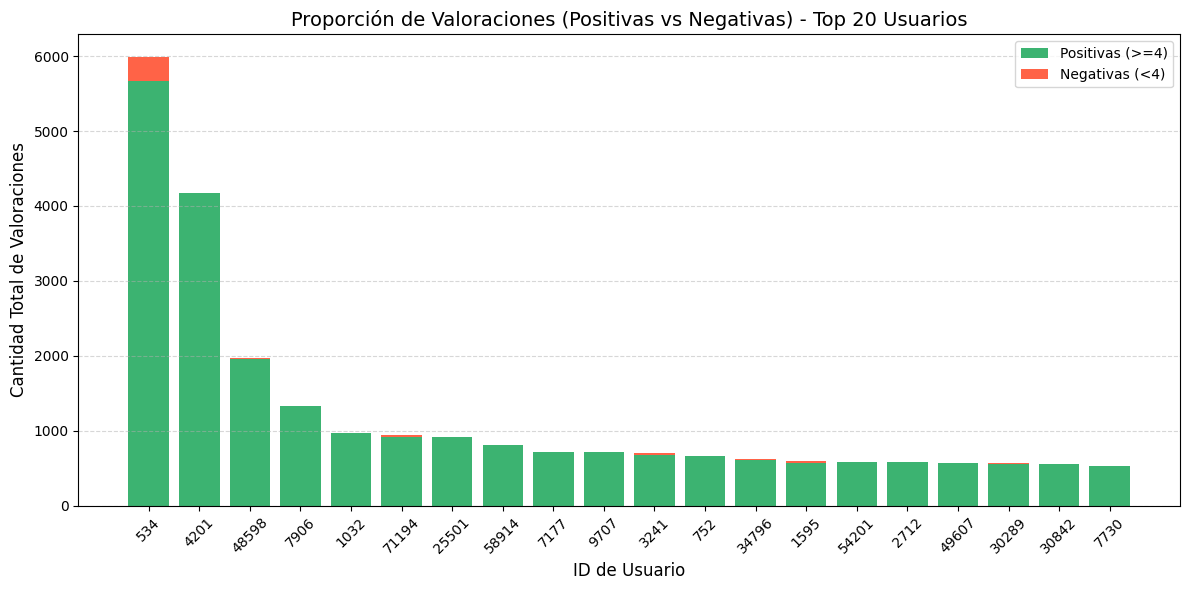

In [16]:
# Sacamos el top 20 de usuarios con más valoraciones en total
top_users = df_posi.sort('total_ratings', descending=True).head(20)

users_ids = [str(uid) for uid in top_users['user'].to_list()] # Convertimos a string para el eje X
pos_counts = top_users['num_positive_ratings'].to_list()
neg_counts = top_users['num_negative_ratings'].to_list()

plt.figure(figsize=(12, 6))

# Barra de positivos
plt.bar(users_ids, pos_counts, color='mediumseagreen', label='Positivas (>=4)')
# Barra de negativos apilada encima (usando el parámetro 'bottom')
plt.bar(users_ids, neg_counts, bottom=pos_counts, color='tomato', label='Negativas (<4)')

plt.title('Proporción de Valoraciones (Positivas vs Negativas) - Top 20 Usuarios', fontsize=14)
plt.xlabel('ID de Usuario', fontsize=12)
plt.ylabel('Cantidad Total de Valoraciones', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

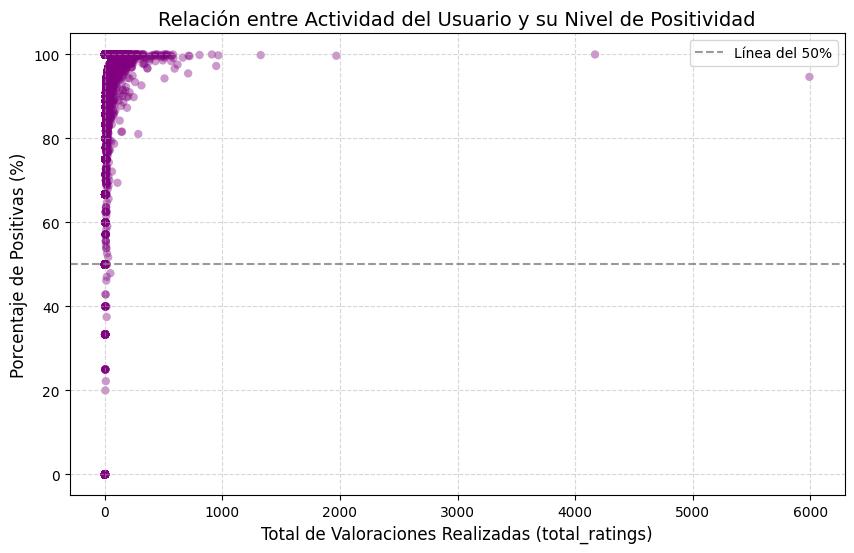

In [17]:
x_total = df_posi['total_ratings'].to_list()
y_porcentaje = df_posi['positive_percentage'].to_list()

plt.figure(figsize=(10, 6))

# Dibujamos los puntos
plt.scatter(x_total, y_porcentaje, color='purple', alpha=0.4, edgecolors='none')

plt.title('Relación entre Actividad del Usuario y su Nivel de Positividad', fontsize=14)
plt.xlabel('Total de Valoraciones Realizadas (total_ratings)', fontsize=12)
plt.ylabel('Porcentaje de Positivas (%)', fontsize=12)

# Opcional: Escala logarítmica si tienes usuarios con miles de votos y otros con solo 1
# plt.xscale('log')

# Línea horizontal del 50% para ver rápidamente quién es más positivo que negativo
plt.axhline(50, color='gray', linestyle='--', alpha=0.8, label='Línea del 50%')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()